1. Setup Awal

In [1]:
# Memastikan Python yang digunakan adalah versi 3.5 atau lebih tinggi
import sys
assert sys.version_info >= (3, 5)

# Memastikan Scikit-Learn yang digunakan adalah versi 0.20 atau lebih tinggi
import sklearn
assert sklearn.__version__ >= "0.20"

# Import library umum
import numpy as np
import os

# Untuk membuat plot/grafik
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

2. PCA Menggunakan SVD

In [2]:
# Membuat data 3D sederhana
np.random.seed(4)
m = 60
w1, w2 = 0.1, 0.3
noise = 0.1
angles = np.random.rand(m) * 3 * np.pi / 2 - 0.5
X = np.empty((m, 3))
X[:, 0] = np.cos(angles) + np.sin(angles)/2 + noise * np.random.randn(m) / 2
X[:, 1] = np.sin(angles) * 0.7 + noise * np.random.randn(m) / 2
X[:, 2] = X[:, 0] * w1 + X[:, 1] * w2 + noise * np.random.randn(m)

# 1. Menormalkan data
X_centered = X - X.mean(axis=0)

# 2. Menggunakan Singular Value Decomposition (SVD)
U, s, Vt = np.linalg.svd(X_centered)

# 3. Mengambil dua principal component pertama
c1 = Vt.T[:, 0]
c2 = Vt.T[:, 1]

# 4. Memproyeksikan data ke bidang 2D
W2 = Vt.T[:, :2]
X2D = X_centered.dot(W2)

print("Bentuk data setelah direduksi:", X2D.shape)

Bentuk data setelah direduksi: (60, 2)


3. PCA Menggunakan Scikit-Learn

In [3]:
from sklearn.decomposition import PCA

# Membuat objek PCA untuk mereduksi data menjadi 2 dimensi
pca = PCA(n_components=2)
X2D_sklearn = pca.fit_transform(X)

# Menampilkan principal components yang ditemukan oleh Scikit-Learn
print("Principal Components dari Scikit-Learn:")
print(pca.components_.T)

Principal Components dari Scikit-Learn:
[[ 0.93636116 -0.34027485]
 [ 0.29854881  0.90119108]
 [ 0.18465208  0.2684542 ]]


4. Explained Variance dan Memilih Jumlah Dimensi

Jumlah dimensi untuk 95% variance: 154


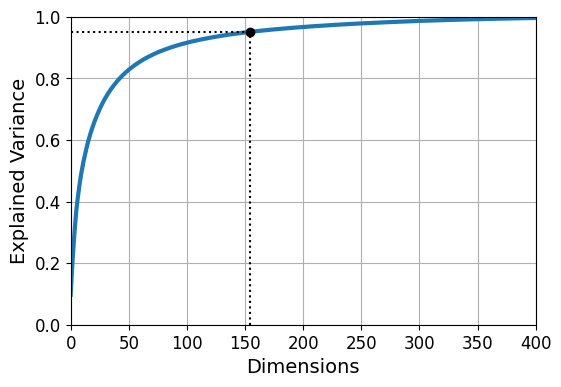

In [4]:
from sklearn.datasets import fetch_openml

# Mengunduh dataset MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Melatih PCA pada seluruh data latih
pca = PCA()
pca.fit(X_train)

# Menghitung kumulatif dari explained variance
cumsum = np.cumsum(pca.explained_variance_ratio_)

# Menentukan jumlah dimensi yang dibutuhkan untuk menyimpan 95% variance
d = np.argmax(cumsum >= 0.95) + 1
print("Jumlah dimensi untuk 95% variance:", d)

# Plotting explained variance
plt.figure(figsize=(6,4))
plt.plot(cumsum, linewidth=3)
plt.axis([0, 400, 0, 1])
plt.xlabel("Dimensions")
plt.ylabel("Explained Variance")
plt.plot([d, d], [0, 0.95], "k:")
plt.plot([0, d], [0.95, 0.95], "k:")
plt.plot(d, 0.95, "ko")
plt.grid(True)
plt.show()

5. PCA untuk Kompresi Gambar (MNIST)

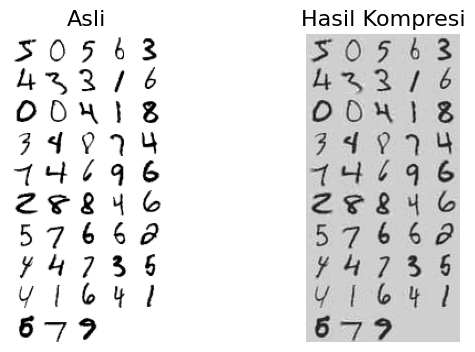

In [5]:
# CATATAN: Kita hanya gunakan sebagian data agar prosesnya cepat
X_train_small = X_train[:10000]

# Melatih PCA untuk mereduksi ke 154 dimensi
pca = PCA(n_components=154)
X_reduced = pca.fit_transform(X_train_small)

# Mengembalikan data ke dimensi asli (dekompresi)
X_recovered = pca.inverse_transform(X_reduced)

# Fungsi untuk plot digit
def plot_digits(instances, images_per_row=5, **options):
    # ... (kode helper untuk plotting, tidak perlu diubah)
    size = 28
    images_per_row = min(len(instances), images_per_row)
    images = [instance.reshape(size,size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap = mpl.cm.binary, **options)
    plt.axis("off")


# Menampilkan gambar asli dan gambar hasil kompresi-dekompresi
plt.figure(figsize=(7, 4))
plt.subplot(121)
plot_digits(X_train_small[::210])
plt.title("Asli", fontsize=16)
plt.subplot(122)
plot_digits(X_recovered[::210])
plt.title("Hasil Kompresi", fontsize=16)
plt.show()

 6. Incremental PCA

In [6]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154)

# Melatih IPCA dengan membagi data menjadi batch-batch kecil
for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

X_reduced_inc = inc_pca.transform(X_train_small)

print("Bentuk data hasil reduksi Incremental PCA:", X_reduced_inc.shape)

Bentuk data hasil reduksi Incremental PCA: (10000, 154)


7. Kernel PCA (kPCA)

In [7]:
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import KernelPCA
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Membuat dataset Swiss Roll
X, t = make_swiss_roll(n_samples=1000, noise=0.2, random_state=42)

# Menggunakan Kernel PCA dengan kernel RBF
rbf_pca = KernelPCA(n_components=2, kernel="rbf", gamma=0.04)
X_reduced = rbf_pca.fit_transform(X)

# Menggunakan GridSearchCV untuk mencari parameter kernel terbaik
# CATATAN: param_grid disederhanakan agar prosesnya sangat cepat
clf = Pipeline([
        ("kpca", KernelPCA(n_components=2)),
        ("log_reg", LogisticRegression(solver="lbfgs"))
    ])

param_grid = [{
        "kpca__gamma": np.linspace(0.03, 0.05, 2), # Coba 2 nilai gamma
        "kpca__kernel": ["rbf", "sigmoid"]
    }]

grid_search = GridSearchCV(clf, param_grid, cv=3)
grid_search.fit(X, t > 6.9) # t > 6.9 adalah target klasifikasi biner sederhana

print("Parameter terbaik dari GridSearchCV:", grid_search.best_params_)

Parameter terbaik dari GridSearchCV: {'kpca__gamma': np.float64(0.05), 'kpca__kernel': 'rbf'}


8. LLE (Locally Linear Embedding)

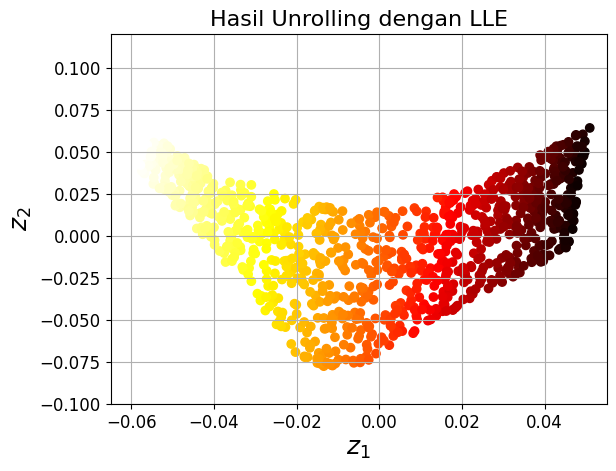

In [8]:
from sklearn.manifold import LocallyLinearEmbedding

# Menggunakan LLE untuk mereduksi dimensi data Swiss Roll
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=42)
X_reduced_lle = lle.fit_transform(X)

# Plot hasil
plt.title("Hasil Unrolling dengan LLE", fontsize=16)
plt.scatter(X_reduced_lle[:, 0], X_reduced_lle[:, 1], c=t, cmap=plt.cm.hot)
plt.xlabel("$z_1$", fontsize=18)
plt.ylabel("$z_2$", fontsize=18)
plt.axis([-0.065, 0.055, -0.1, 0.12])
plt.grid(True)
plt.show()

Penjelasan Kode
Bagian 1. Setup Awal: Persiapan library standar.

Bagian 2 & 3. PCA (Principal Component Analysis): Ini adalah teknik reduksi dimensi paling populer.

Tujuan: PCA mencari sumbu-sumbu baru (disebut principal components) di dalam data, di mana setiap sumbu baru ini menangkap variasi (informasi) data sebanyak mungkin. Sumbu-sumbu ini diurutkan dari yang paling penting hingga yang paling tidak penting.

Cara Kerja: Bagian 2 menunjukkan cara kerja PCA secara manual menggunakan dekomposisi matriks SVD (Singular Value Decomposition). Bagian 3 menunjukkan cara yang jauh lebih praktis menggunakan class PCA dari Scikit-Learn. Keduanya akan memberikan hasil yang sama.

Bagian 4. Explained Variance: Bagaimana cara memilih jumlah dimensi yang tepat? explained_variance_ratio_ adalah atribut PCA yang sangat penting. Atribut ini memberitahu kita berapa persen dari total informasi (varians) data yang ditangkap oleh setiap principal component. Dengan membuat plot kumulatifnya, kita bisa memutuskan untuk menyimpan sejumlah dimensi yang cukup untuk mempertahankan, misalnya, 95% dari informasi asli.

Bagian 5. PCA untuk Kompresi: Salah satu kegunaan utama PCA adalah untuk kompresi data. Di sini, 784 fitur (piksel) dari gambar MNIST direduksi menjadi hanya 154 fitur. Ini secara signifikan mengurangi ukuran data. Metode inverse_transform digunakan untuk mengembalikan data ke 784 dimensi semula. Tentu saja, proses ini bersifat lossy (ada informasi yang hilang), sehingga gambar hasil dekompresi akan terlihat sedikit lebih buram.

Bagian 6. Incremental PCA (IPCA): Ini adalah varian dari PCA yang berguna untuk dataset yang sangat besar dan tidak muat di memori. IPCA bekerja dengan memproses data dalam potongan-potongan kecil (mini-batches) satu per satu.

Bagian 7. Kernel PCA (kPCA): PCA adalah teknik linier. Jika data Anda memiliki struktur yang kompleks dan non-linier (seperti gulungan Swiss Roll), PCA biasa tidak akan bekerja dengan baik. kPCA menggunakan kernel trick (seperti pada SVM) untuk memproyeksikan data ke dimensi yang sangat tinggi di mana data tersebut menjadi bisa dipisahkan secara linier, lalu menerapkan PCA di sana. Ini memungkinkan kPCA untuk menangani manifold non-linier yang rumit. GridSearchCV digunakan untuk mencari kombinasi kernel dan gamma terbaik secara otomatis.

Bagian 8. LLE (Locally Linear Embedding): Ini adalah teknik reduksi dimensi non-linier lainnya, yang termasuk dalam kategori Manifold Learning. Berbeda dengan PCA yang mencoba mempertahankan varians global, LLE bekerja dengan cara melihat hubungan lokal setiap titik data dengan tetangga terdekatnya. Kemudian, ia mencoba untuk merekonstruksi data di dimensi yang lebih rendah sambil tetap mempertahankan hubungan ketetanggaan tersebut. Ini membuatnya sangat baik dalam "membuka" atau "memipihkan" manifold yang terlipat seperti Swiss Roll.